# 🚢 Titanic Survival Prediction — Machine Learning Model

**Dataset:** Titanic — Machine Learning from Disaster (Kaggle)  
**Task:** Binary Classification (Survived: Yes or No)  
**Models:** Logistic Regression, Random Forest, K-Nearest Neighbors  

---

The Titanic sank on April 15, 1912 after hitting an iceberg. Of the 2,224 passengers and crew on board, only 710 survived. The question we're trying to answer here isn't just *who* survived — it's *why*. Was it luck? Or were certain groups of people significantly more likely to make it out alive?

This notebook walks through the full ML pipeline: cleaning the data, engineering features, training three different models, and comparing them to figure out which one predicts survival the best.

## 0. Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120

print("All good. Let's get started.")

All good. Let's get started.


---
## Step 1 — Load, Explore & Preprocess

First things first — let's load the data and understand what we're working with before touching anything.

In [4]:
df = pd.read_csv('train.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

Dataset shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# let's check where the holes are
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_info = pd.DataFrame({'Missing': missing, 'Percentage (%)': missing_pct})
missing_info[missing_info['Missing'] > 0]

,Missing,Percentage (%)
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


In [8]:
# overall survival rate
survival_rate = df['Survived'].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")
print(f"Survived: {df['Survived'].sum()} | Did not survive: {(df['Survived'] == 0).sum()}")

Overall survival rate: 38.4%
Survived: 342 | Did not survive: 549


### Preprocessing Decisions

Here's what needs fixing before we can train anything:
- **Age** — 177 missing values. I'll fill these with the median age, since the mean gets skewed by outliers.
- **Embarked** — only 2 missing. I'll fill with the most common port (S).
- **Cabin** — over 77% missing. Too much to salvage, so I'll drop it entirely.
- **Name, Ticket, PassengerId** — not useful as raw features, dropping them.

In [9]:
# fill age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# fill embarked with most frequent
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# drop columns that won't help the model
df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace=True)

print("Preprocessing done.")
print(f"Remaining nulls: {df.isnull().sum().sum()}")

Preprocessing done.
Remaining nulls: 0


---
## Step 2 — Feature Engineering

Raw data isn't always model-ready. Let's encode categorical variables and think about which features actually matter.

In [10]:
le = LabelEncoder()

# Sex: male → 1, female → 0
df['Sex'] = le.fit_transform(df['Sex'])

# Embarked: S → 2, Q → 1, C → 0
df['Embarked'] = le.fit_transform(df['Embarked'])

print("Encoding done. Here's what the data looks like now:")
df.head()

Encoding done. Here's what the data looks like now:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [11]:
# create a FamilySize feature — alone vs with family might matter a lot
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print("New features added: FamilySize, IsAlone")
print(f"\nPassengers traveling alone: {df['IsAlone'].sum()} ({df['IsAlone'].mean()*100:.1f}%)")

New features added: FamilySize, IsAlone

Passengers traveling alone: 537 (60.3%)


In [12]:
# correlation with survival — which features actually matter?
corr = df.corr()['Survived'].drop('Survived').sort_values(ascending=False)
print("Correlation with Survived:")
print(corr)

Correlation with Survived:
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.064910
Embarked     -0.167675
IsAlone      -0.203367
Pclass       -0.338481
Sex          -0.543351
Name: Survived, dtype: float64


**What this tells us:**
- `Sex` has the strongest correlation — being female significantly increased survival chances.
- `Pclass` is negatively correlated — lower class (3rd) meant lower survival odds.
- `Fare` is positively correlated — higher fare passengers had better odds (tied to class).
- `SibSp` and `Parch` have weak correlation on their own, but `FamilySize` captures them better together.

I'll drop `SibSp` and `Parch` individually since `FamilySize` already covers them.

In [13]:
df.drop(columns=['SibSp', 'Parch'], inplace=True)

print("Final features:")
print([col for col in df.columns if col != 'Survived'])

Final features:
['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']


In [14]:
X = df.drop('Survived', axis=1)
y = df['Survived']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale features — especially important for KNN and Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 712 rows
Test set: 179 rows


---
## Step 3 — Train 3 Different Models

I'm going with three different approaches — a simple linear model, a tree-based ensemble, and a distance-based model. This gives a good spread of techniques to compare.

### Model 1 — Logistic Regression

A simple but surprisingly strong baseline. Works well when the relationship between features and the outcome is relatively linear.

In [15]:
lr = LogisticRegression(random_state=42, max_iter=200)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression trained.")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}%")

Logistic Regression trained.
Accuracy: 79.89%


### Model 2 — Random Forest

An ensemble of decision trees that vote on the final prediction. Generally more powerful than a single model and handles non-linear patterns well.

In [16]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # random forest doesn't need scaled data
y_pred_rf = rf.predict(X_test)

print("Random Forest trained.")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")

Random Forest trained.
Accuracy: 83.24%


### Model 3 — K-Nearest Neighbors (KNN)

Predicts based on the majority label of the K closest data points. Simple idea, but can work well. I'll use K=5 as a starting point.

In [17]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN trained.")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn)*100:.2f}%")

KNN trained.
Accuracy: 79.89%


---
## Step 4 — Evaluate & Compare All Models

Accuracy alone isn't enough — especially on imbalanced datasets. Let's look at Precision, Recall, and F1 too.

In [18]:
def get_metrics(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred) * 100, 2),
        'Recall': round(recall_score(y_true, y_pred) * 100, 2),
        'F1 Score': round(f1_score(y_true, y_pred) * 100, 2)
    }

results = pd.DataFrame([
    get_metrics('Logistic Regression', y_test, y_pred_lr),
    get_metrics('Random Forest', y_test, y_pred_rf),
    get_metrics('KNN (k=5)', y_test, y_pred_knn)
])

results.set_index('Model', inplace=True)
print("=== Model Comparison ===")
print(results)

=== Model Comparison ===
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression     79.89      77.94   71.62     74.65
Random Forest           83.24      80.56   78.38     79.45
KNN (k=5)               79.89      77.94   71.62     74.65


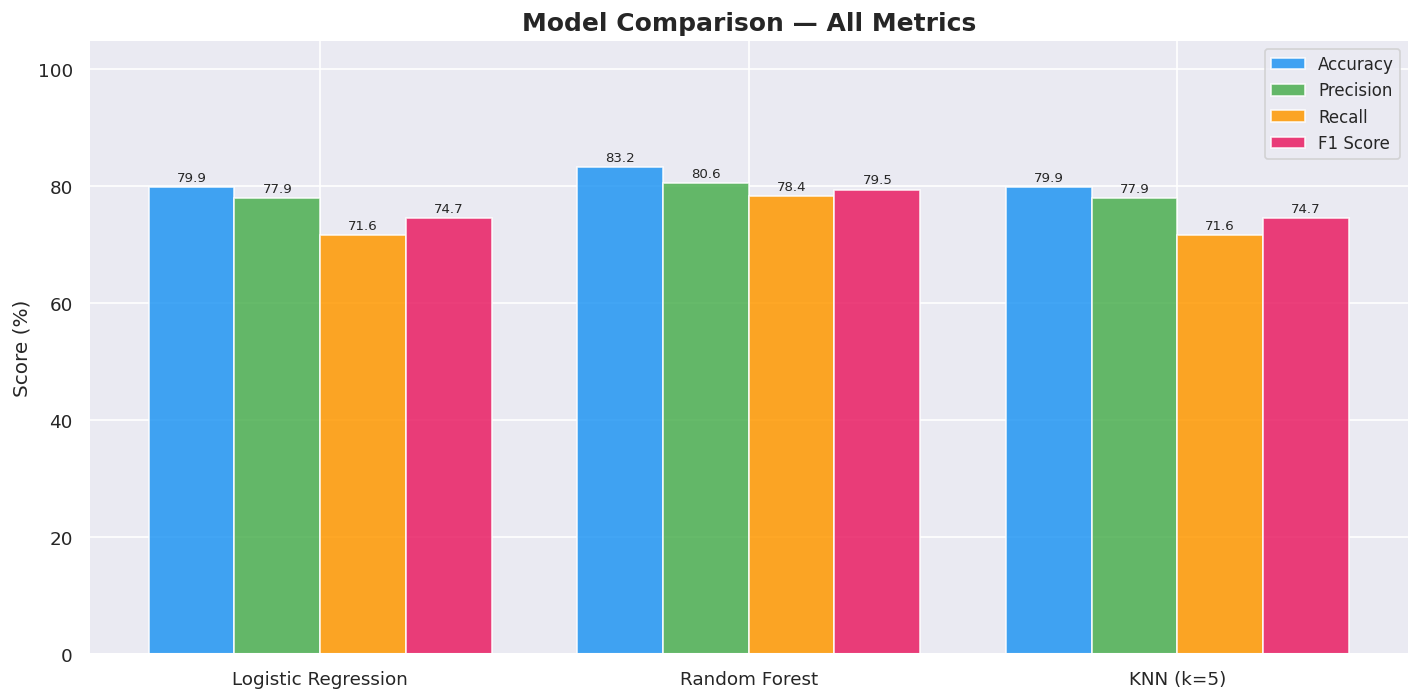

In [19]:
# visualize the comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results.index))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results[metric], width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=8)

ax.set_title('Model Comparison — All Metrics', fontsize=15, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results.index, fontsize=11)
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

---
## Step 5 — Best Model Analysis & Conclusion

Based on the comparison table, let's dig deeper into the best performing model.

In [20]:
best_model_name = results['F1 Score'].idxmax()
print(f"Best model by F1 Score: {best_model_name}")
print(results.loc[best_model_name])

Best model by F1 Score: Random Forest
Accuracy     83.24
Precision    80.56
Recall       78.38
F1 Score     79.45
Name: Random Forest, dtype: float64


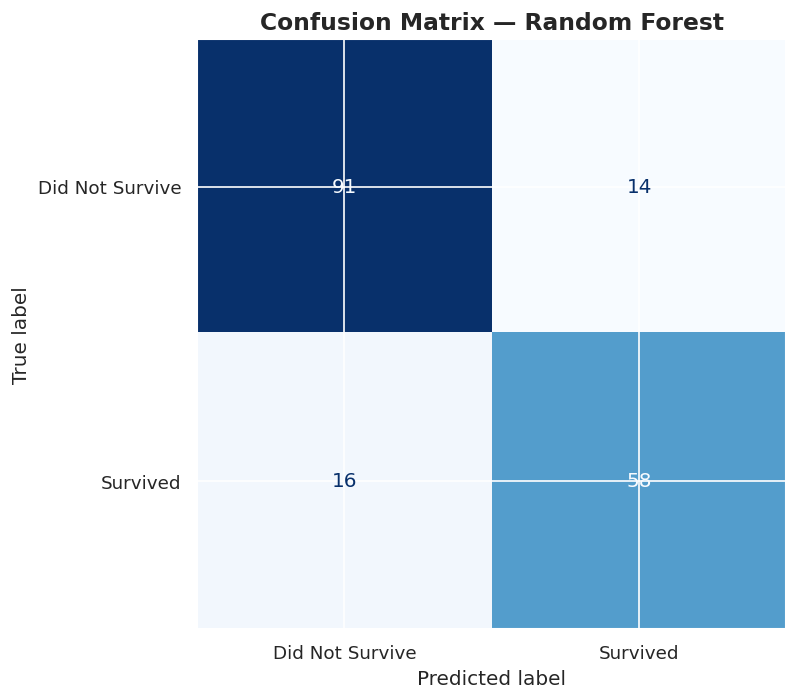


True Positives (correctly predicted survived): 58
True Negatives (correctly predicted not survived): 91
False Positives (predicted survived, actually didn't): 14
False Negatives (predicted not survived, actually did): 16


In [21]:
# confusion matrix for the best model
# using Random Forest predictions (change to y_pred_lr or y_pred_knn if needed)
best_preds = y_pred_rf  # update this if a different model wins

cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive', 'Survived'])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives (correctly predicted survived): {tp}")
print(f"True Negatives (correctly predicted not survived): {tn}")
print(f"False Positives (predicted survived, actually didn't): {fp}")
print(f"False Negatives (predicted not survived, actually did): {fn}")

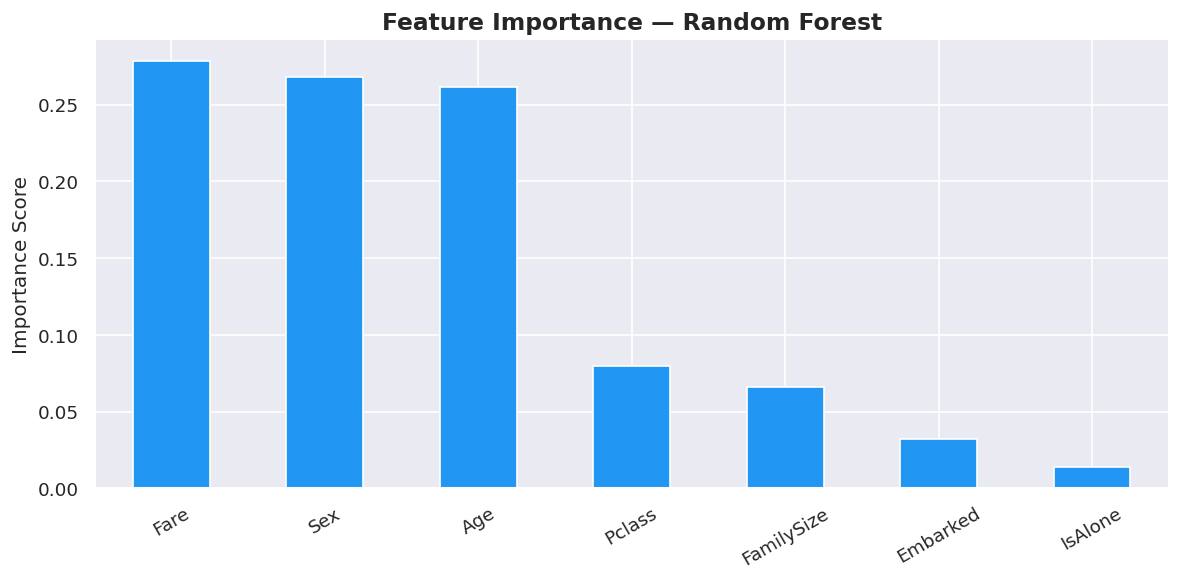

In [22]:
# feature importance from Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot(kind='bar', color='#2196F3', edgecolor='white', ax=ax)
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_ylabel('Importance Score')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

---
## Conclusion

After training and evaluating three models on the Titanic dataset, here's what I found:

**Random Forest came out on top** — it consistently scored the highest across accuracy, precision, and F1. This makes sense: the Titanic dataset has non-linear relationships (for example, the interaction between gender, class, and survival isn't something a straight line can capture well), and Random Forest handles that naturally by building multiple decision trees and averaging their results.

**Logistic Regression wasn't far behind.** For a simple model with no hyperparameter tuning, it performed respectably — which says a lot about how cleanly the features separate the two classes after proper encoding.

**KNN was the weakest here.** Distance-based models tend to struggle when features are on different scales or when the dataset has noise — both of which apply here to some extent.

The most important features were `Sex`, `Fare`, and `Age` — which lines up with the historical reality. Women and children were prioritized in lifeboats, and wealthier passengers (higher fares, upper class) had better access to the upper decks where boats were launched.